In [27]:
all_model_results = []

In [5]:
#necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [28]:
all_model_results = [] # Initialize global list to store results for all models and datasets

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Ensure numpy is imported

def train_and_evaluate_model(model, model_name, X_train_proc, y_train, X_test_proc, y_test, dataset_type, results_list):
    print(f"\n--- Training {model_name} Model on {dataset_type} Data---")
    model.fit(X_train_proc, y_train)

    # Predictions for training set
    y_train_pred = model.predict(X_train_proc)
    y_train_pred_proba = model.predict_proba(X_train_proc)[:, 1]

    # Predictions for test set
    y_test_pred = model.predict(X_test_proc)
    y_test_pred_proba = model.predict_proba(X_test_proc)[:, 1]

    # Calculate metrics for training set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='binary', zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, average='binary', zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, average='binary', zero_division=0)
    train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

    # Calculate metrics for test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='binary', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='binary', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='binary', zero_division=0)
    test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

    print(f"\n--- {model_name} Performance (Training Set - {dataset_type}) ---")
    print(classification_report(y_train, y_train_pred, zero_division=0))
    print(f"ROC AUC Score (Train): {train_roc_auc:.2f}")

    print(f"\n--- {model_name} Performance (Test Set - {dataset_type}) ---")
    print(classification_report(y_test, y_test_pred, zero_division=0))
    print(f"ROC AUC Score (Test): {test_roc_auc:.2f}")

    # Plot ROC Curve for test set
    fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {test_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name} ({dataset_type} Test Set)')
    plt.legend(loc="lower right")
    plt.show()

    results_list.append({
        'Model': model_name,
        'Dataset_Strategy': dataset_type,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Train_Precision': train_precision,
        'Test_Precision': test_precision,
        'Train_Recall': train_recall,
        'Test_Recall': test_recall,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'Train_ROC_AUC': train_roc_auc,
        'Test_ROC_AUC': test_roc_auc
    })


--- Preparing Data for Undersampling Strategy ---

--- Training Logistic Regression Model on Undersampled Data---

--- Logistic Regression Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.65      0.62      0.63        64
           1       0.64      0.66      0.65        64

    accuracy                           0.64       128
   macro avg       0.64      0.64      0.64       128
weighted avg       0.64      0.64      0.64       128

ROC AUC Score (Train): 0.75

--- Logistic Regression Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32

ROC AUC Score (Test): 0.52


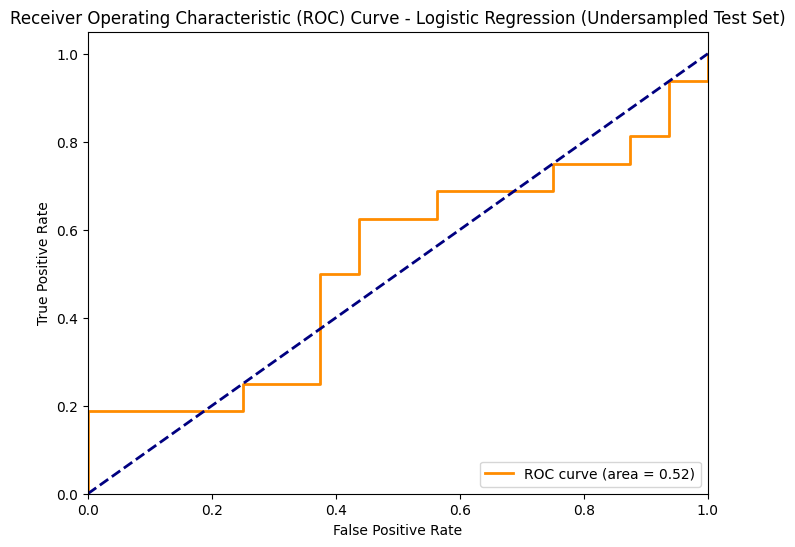


--- Training Decision Tree Model on Undersampled Data---

--- Decision Tree Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        64

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128

ROC AUC Score (Train): 1.00

--- Decision Tree Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.53      0.56      0.55        16
           1       0.53      0.50      0.52        16

    accuracy                           0.53        32
   macro avg       0.53      0.53      0.53        32
weighted avg       0.53      0.53      0.53        32

ROC AUC Score (Test): 0.53


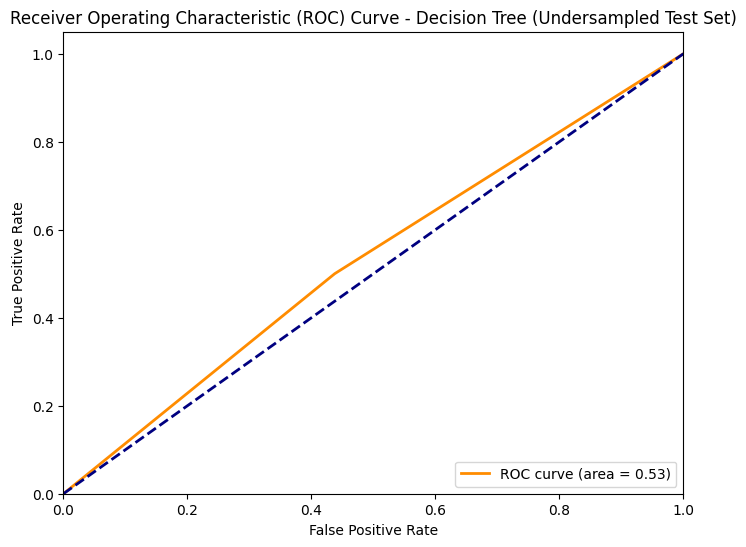


--- Training Random Forest Model on Undersampled Data---

--- Random Forest Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        64

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128

ROC AUC Score (Train): 1.00

--- Random Forest Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.47      0.44      0.45        16
           1       0.47      0.50      0.48        16

    accuracy                           0.47        32
   macro avg       0.47      0.47      0.47        32
weighted avg       0.47      0.47      0.47        32

ROC AUC Score (Test): 0.55


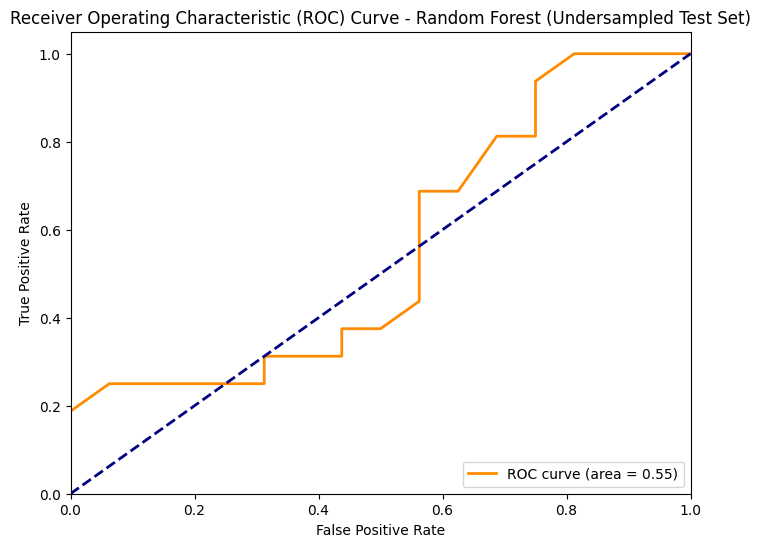


--- Training XGBoost Model on Undersampled Data---

--- XGBoost Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        64

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128

ROC AUC Score (Train): 1.00

--- XGBoost Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.47      0.50      0.48        16
           1       0.47      0.44      0.45        16

    accuracy                           0.47        32
   macro avg       0.47      0.47      0.47        32
weighted avg       0.47      0.47      0.47        32

ROC AUC Score (Test): 0.44


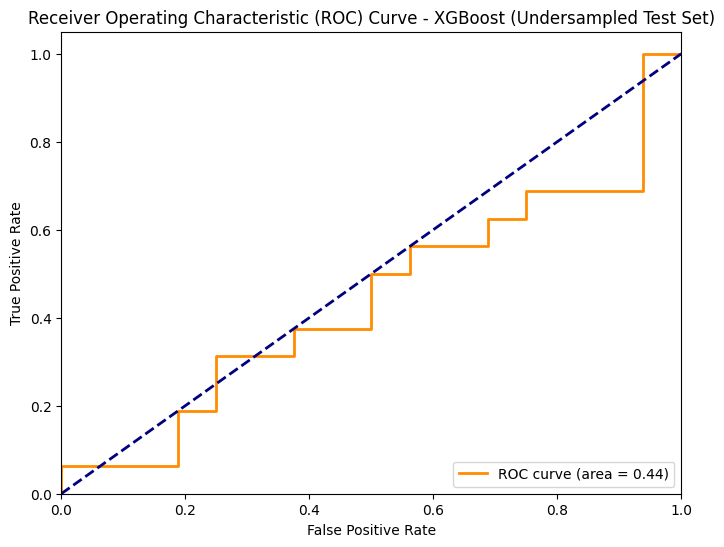

In [30]:
# --- Data Loading and Preprocessing (Undersampled Data) --- (from bWIYFGfhgEuU, wPP1BD5dldgF, 35jsGl3_nxZG, iEu4uKwxpRoM, 8i43s5eWc18G, 10d41c62, c1679519)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n--- Preparing Data for Undersampling Strategy ---")

df_undersample = pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

# Impute missing values
numerical_cols_with_nan_us = ['Income', 'Credit_Score', 'Loan_Balance']
for col in numerical_cols_with_nan_us:
    df_undersample[col].fillna(df_undersample[col].mean(), inplace=True)

# Standardize 'Employment_Status'
df_undersample['Employment_Status'] = df_undersample['Employment_Status'].replace({
    'EMP': 'Employed',
    'employed': 'Employed',
    'EM': 'Employed'
})
df_undersample['Employment_Status'] = df_undersample['Employment_Status'].str.title()

# Separate majority and minority classes
df_majority_us = df_undersample[df_undersample['Delinquent_Account'] == 0]
df_minority_us = df_undersample[df_undersample['Delinquent_Account'] == 1]

# Undersample majority class to match minority class size
df_majority_undersampled = df_majority_us.sample(n=len(df_minority_us), random_state=42)

# Concatenate minority class with undersampled majority class
df_small = pd.concat([df_majority_undersampled, df_minority_us])

# Shuffle the new DataFrame to ensure randomness
df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop 'Customer_ID' and define target/features
df_model_balanced_us = df_small.drop(columns=['Customer_ID'], errors='ignore')
X_us = df_model_balanced_us.drop('Delinquent_Account', axis=1)
y_us = df_model_balanced_us['Delinquent_Account']

# Train-Test Split
X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(X_us, y_us, test_size=0.2, random_state=42, stratify=y_us)

# Identify numerical and categorical columns for preprocessing
numerical_cols_us = X_us.select_dtypes(include=np.number).columns.tolist()
categorical_cols_us = X_us.select_dtypes(include='object').columns.tolist()

# Create a column transformer to apply different transformations to different columns
preprocessor_us = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), numerical_cols_us),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols_us)
    ])

# Apply the preprocessor to the training and testing data
X_train_processed_us = preprocessor_us.fit_transform(X_train_us)
X_test_processed_us = preprocessor_us.transform(X_test_us)

# --- Train models on Undersampled Data ---

# Logistic Regression
log_reg_model_us = LogisticRegression(random_state=42, solver='liblinear')
train_and_evaluate_model(log_reg_model_us, 'Logistic Regression', X_train_processed_us, y_train_us, X_test_processed_us, y_test_us, 'Undersampled', all_model_results)

# Decision Tree Classifier
dt_model_us = DecisionTreeClassifier(random_state=42)
train_and_evaluate_model(dt_model_us, 'Decision Tree', X_train_processed_us, y_train_us, X_test_processed_us, y_test_us, 'Undersampled', all_model_results)

# Random Forest Classifier
rf_model_us = RandomForestClassifier(random_state=42)
train_and_evaluate_model(rf_model_us, 'Random Forest', X_train_processed_us, y_train_us, X_test_processed_us, y_test_us, 'Undersampled', all_model_results)

# XGBoost Classifier
xgb_model_us = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
train_and_evaluate_model(xgb_model_us, 'XGBoost', X_train_processed_us, y_train_us, X_test_processed_us, y_test_us, 'Undersampled', all_model_results)


--- Preparing Data with SMOTE Strategy ---
Original X_train shape (before SMOTE): (400, 17)
y_train shape (before SMOTE): (400,)
X_train shape after processing and SMOTE: (672, 40)
y_train shape after SMOTE: (672,)
X_test shape after processing: (100, 40)
y_test shape: (100,)

--- Training Logistic Regression Model on SMOTE Data---

--- Logistic Regression Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       336
           1       0.66      0.74      0.69       336

    accuracy                           0.67       672
   macro avg       0.68      0.67      0.67       672
weighted avg       0.68      0.67      0.67       672

ROC AUC Score (Train): 0.72

--- Logistic Regression Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.83      0.57      0.68        84
           1       0.14      0.38      0.21        16

    accuracy          

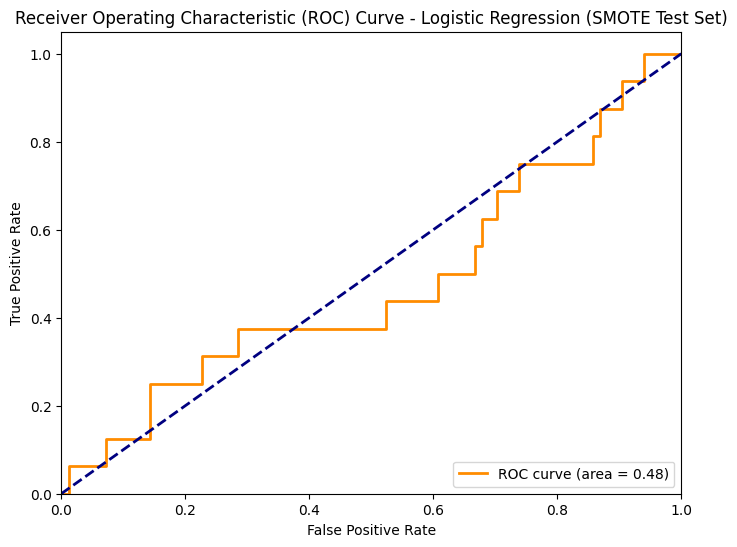


--- Training Decision Tree Model on SMOTE Data---

--- Decision Tree Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       336

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

ROC AUC Score (Train): 1.00

--- Decision Tree Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        84
           1       0.05      0.06      0.05        16

    accuracy                           0.64       100
   macro avg       0.43      0.41      0.42       100
weighted avg       0.69      0.64      0.66       100

ROC AUC Score (Test): 0.41


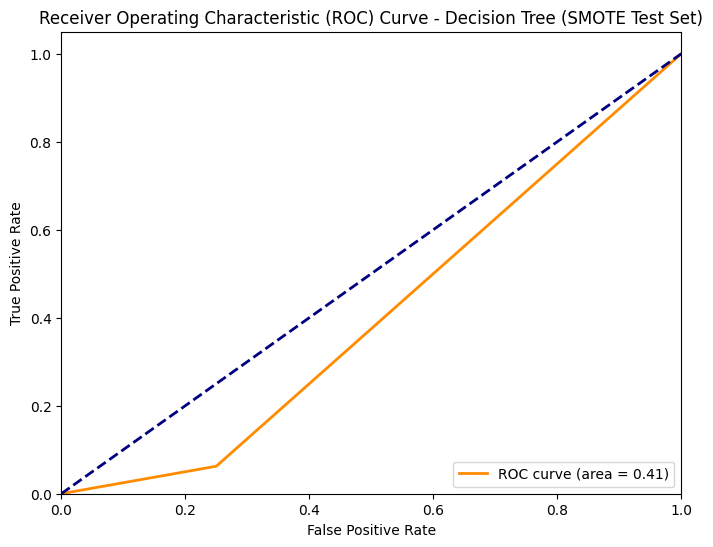


--- Training Random Forest Model on SMOTE Data---

--- Random Forest Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       336

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

ROC AUC Score (Train): 1.00

--- Random Forest Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.84      0.99      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.83       100
   macro avg       0.42      0.49      0.45       100
weighted avg       0.70      0.83      0.76       100

ROC AUC Score (Test): 0.45


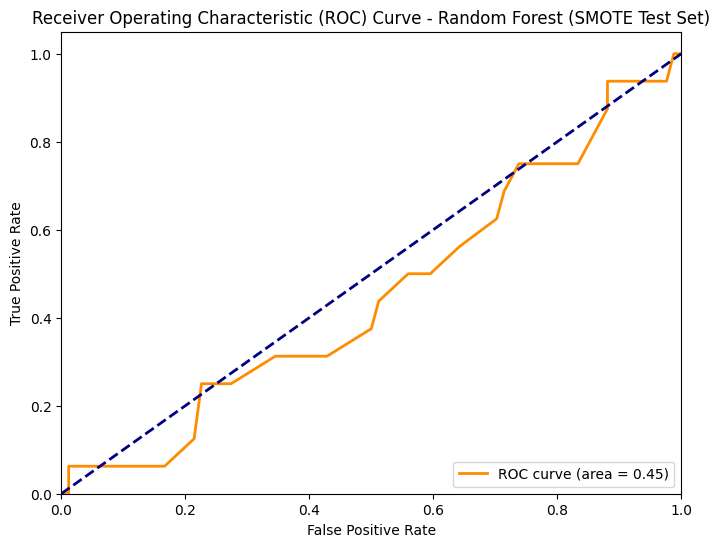


--- Training XGBoost Model on SMOTE Data---

--- XGBoost Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       336

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

ROC AUC Score (Train): 1.00

--- XGBoost Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        84
           1       0.00      0.00      0.00        16

    accuracy                           0.79       100
   macro avg       0.42      0.47      0.44       100
weighted avg       0.70      0.79      0.74       100

ROC AUC Score (Test): 0.36


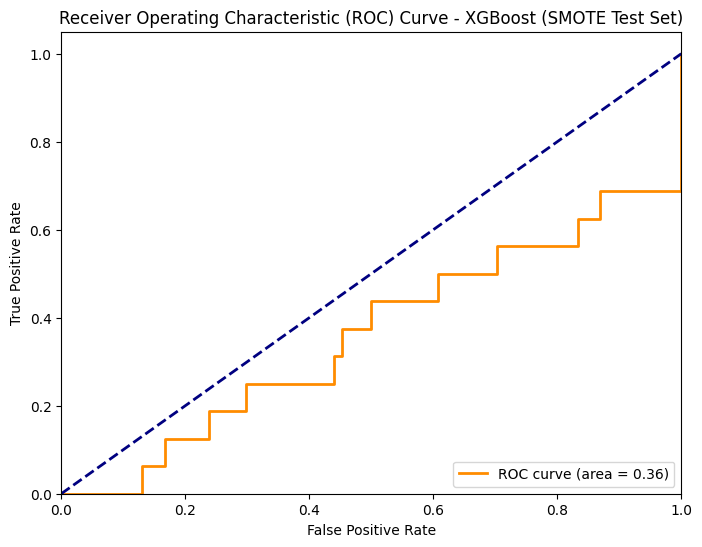

In [31]:
# --- Data Loading and Preprocessing (SMOTE Data) --- (from bWIYFGfhgEuU, wPP1BD5dldgF, 35jsGl3_nxZG, new_smote_cell)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n--- Preparing Data with SMOTE Strategy ---")

df_smote = pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

# Impute missing values
numerical_cols_with_nan_smote = ['Income', 'Credit_Score', 'Loan_Balance']
for col in numerical_cols_with_nan_smote:
    df_smote[col].fillna(df_smote[col].mean(), inplace=True)

# Standardize 'Employment_Status'
df_smote['Employment_Status'] = df_smote['Employment_Status'].replace({
    'EMP': 'Employed',
    'employed': 'Employed',
    'EM': 'Employed'
})
df_smote['Employment_Status'] = df_smote['Employment_Status'].str.title()

# Start with the original processed df (after imputation and standardization)
df_for_smote_prep = df_smote.drop(columns=['Customer_ID'], errors='ignore')
X_smote_base = df_for_smote_prep.drop('Delinquent_Account', axis=1)
y_smote_base = df_for_smote_prep['Delinquent_Account']

# Split into training and test sets *before* SMOTE to prevent data leakage
X_train_raw_smote, X_test_raw_smote, y_train_raw_smote, y_test_raw_smote = train_test_split(
    X_smote_base, y_smote_base, test_size=0.2, random_state=42, stratify=y_smote_base
)

# Identify numerical and categorical columns for preprocessing
numerical_cols_smote = X_smote_base.select_dtypes(include=np.number).columns.tolist()
categorical_cols_smote = X_smote_base.select_dtypes(include='object').columns.tolist()

# Create a ColumnTransformer for SMOTE data processing
smote_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), numerical_cols_smote),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols_smote)
    ])

# Fit and transform the preprocessor on the *training* data (before SMOTE)
X_train_processed_smote_initial = smote_preprocessor.fit_transform(X_train_raw_smote)
# Transform the *test* data using the fitted preprocessor
X_test_processed_smote = smote_preprocessor.transform(X_test_raw_smote)

# Apply SMOTE to the *processed training data*
smote = SMOTE(random_state=42)
X_train_processed_smote, y_train_processed_smote = smote.fit_resample(X_train_processed_smote_initial, y_train_raw_smote)

print(f"Original X_train shape (before SMOTE): {X_train_raw_smote.shape}")
print(f"y_train shape (before SMOTE): {y_train_raw_smote.shape}")
print(f"X_train shape after processing and SMOTE: {X_train_processed_smote.shape}")
print(f"y_train shape after SMOTE: {y_train_processed_smote.shape}")
print(f"X_test shape after processing: {X_test_processed_smote.shape}")
print(f"y_test shape: {y_test_raw_smote.shape}")

# --- Train models on SMOTE Data ---

# Logistic Regression
log_reg_model_smote = LogisticRegression(random_state=42, solver='liblinear')
train_and_evaluate_model(log_reg_model_smote, 'Logistic Regression', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# Decision Tree Classifier
dt_model_smote = DecisionTreeClassifier(random_state=42)
train_and_evaluate_model(dt_model_smote, 'Decision Tree', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# Random Forest Classifier
rf_model_smote = RandomForestClassifier(random_state=42)
train_and_evaluate_model(rf_model_smote, 'Random Forest', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# XGBoost Classifier
xgb_model_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
train_and_evaluate_model(xgb_model_smote, 'XGBoost', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

In [32]:
# Display all results in a DataFrame
print("\n--- Comprehensive Model Performance Comparison ---")
display(pd.DataFrame(all_model_results).round(2))


--- Comprehensive Model Performance Comparison ---


,Model,Dataset_Strategy,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC
0,Logistic Regression,Undersampled,0.64,0.59,0.64,0.59,0.66,0.62,0.65,0.61,0.75,0.52
1,Decision Tree,Undersampled,1.00,0.53,1.00,0.53,1.00,0.50,1.00,0.52,1.00,0.53
2,Random Forest,Undersampled,1.00,0.47,1.00,0.47,1.00,0.50,1.00,0.48,1.00,0.55
3,XGBoost,Undersampled,1.00,0.47,1.00,0.47,1.00,0.44,1.00,0.45,1.00,0.44
4,Logistic Regression,SMOTE,0.67,0.54,0.66,0.14,0.74,0.38,0.69,0.21,0.72,0.48
5,Decision Tree,SMOTE,1.00,0.64,1.00,0.05,1.00,0.06,1.00,0.05,1.00,0.41
6,Random Forest,SMOTE,1.00,0.83,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.45
7,XGBoost,SMOTE,1.00,0.79,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.36


In [6]:
df=pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [8]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [9]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,39
Credit_Score,2
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,29
Debt_to_Income_Ratio,0
Employment_Status,0


In [10]:
print(df.duplicated()/len(df)*100)

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
495    0.0
496    0.0
497    0.0
498    0.0
499    0.0
Length: 500, dtype: float64


In [11]:
print(df.isnull().sum()/len(df)*100)

Customer_ID             0.0
Age                     0.0
Income                  7.8
Credit_Score            0.4
Credit_Utilization      0.0
Missed_Payments         0.0
Delinquent_Account      0.0
Loan_Balance            5.8
Debt_to_Income_Ratio    0.0
Employment_Status       0.0
Account_Tenure          0.0
Credit_Card_Type        0.0
Location                0.0
Month_1                 0.0
Month_2                 0.0
Month_3                 0.0
Month_4                 0.0
Month_5                 0.0
Month_6                 0.0
dtype: float64


Given the fact that the number of records are less in the given dataset, it would be not be sensible to remove the records with null values. Hence, we would fill the missing data using mean or median (after observing the distribution)

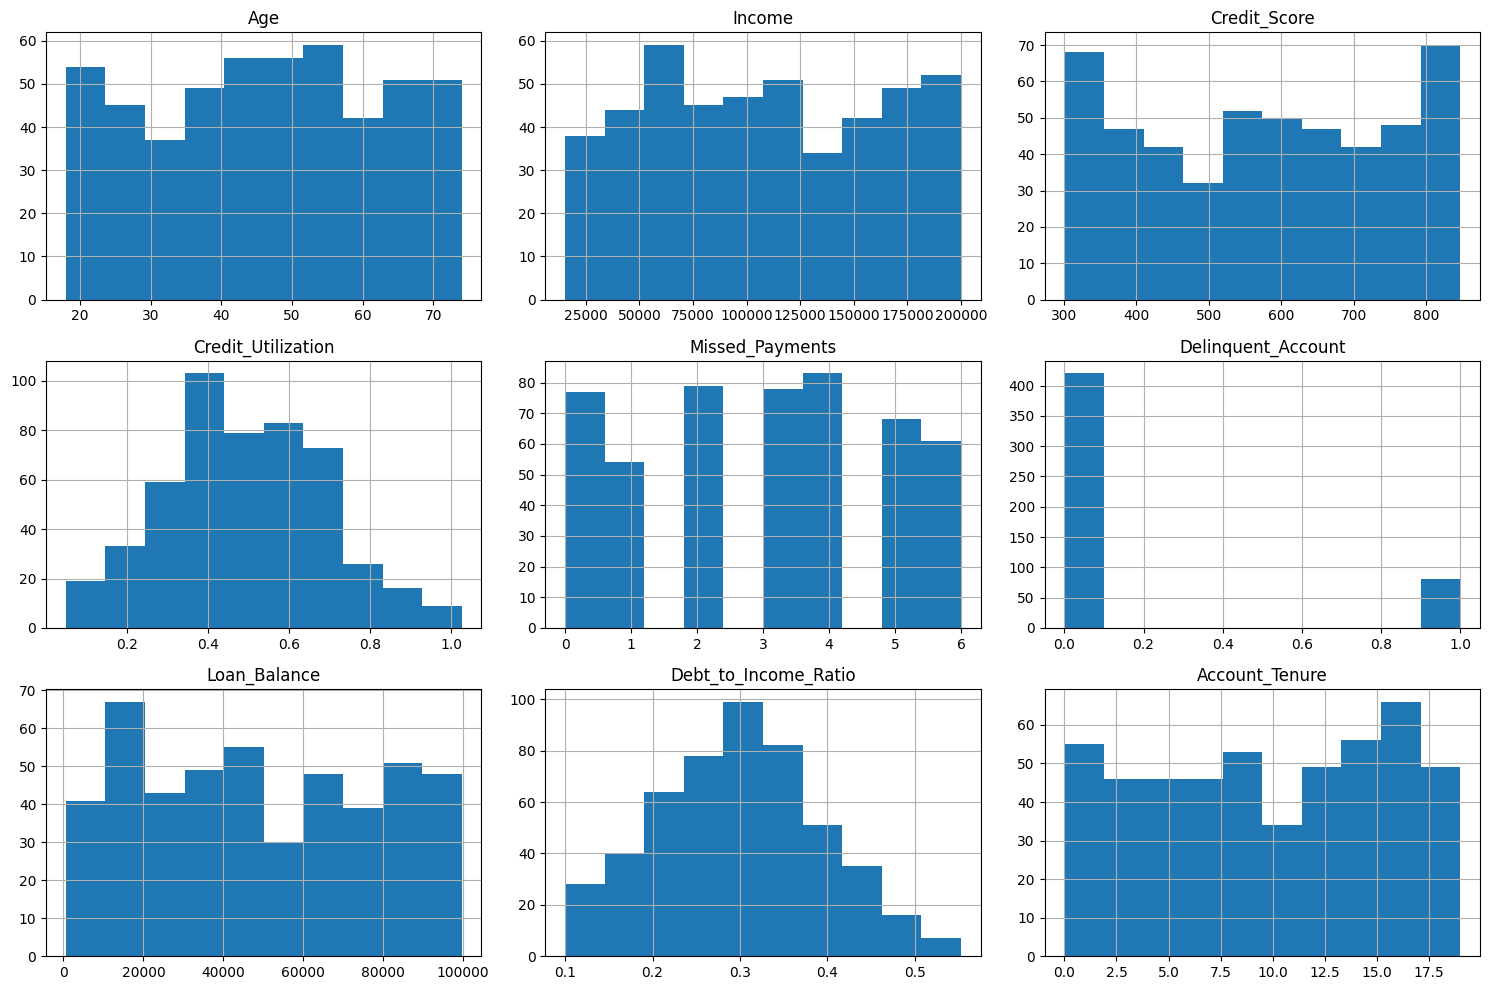

In [12]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [13]:
numerical_cols_with_nan = ['Income', 'Credit_Score', 'Loan_Balance']

for col in numerical_cols_with_nan:
    df[col].fillna(df[col].mean(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after imputation:
Series([], dtype: int64)


In [14]:
print("\n--- Checking Object Columns for Multiple Mappings ---")
object_cols = df.select_dtypes(include='object').columns

columns_to_check = [col for col in object_cols if col not in ['Customer_ID', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']]

for col in columns_to_check:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())
    print("-----------------------------------------")

if 'Employment_Status' in columns_to_check:
    print("\nStandardizing 'Employment_Status'...")
    df['Employment_Status'] = df['Employment_Status'].replace({
        'EMP': 'Employed',
        'employed': 'Employed',
        'EM': 'Employed'
    })
    df['Employment_Status'] = df['Employment_Status'].str.title()
    print(f"Unique values in 'Employment_Status' after standardization:")
    print(df['Employment_Status'].value_counts())

print("\nMultiple mapping check and standardization complete for identified columns.")


--- Checking Object Columns for Multiple Mappings ---

Unique values in 'Employment_Status':
Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64
-----------------------------------------

Unique values in 'Credit_Card_Type':
Credit_Card_Type
Gold        118
Student     112
Business    108
Standard     86
Platinum     76
Name: count, dtype: int64
-----------------------------------------

Unique values in 'Location':
Location
Los Angeles    107
Phoenix        103
Chicago        103
Houston         95
New York        92
Name: count, dtype: int64
-----------------------------------------

Standardizing 'Employment_Status'...
Unique values in 'Employment_Status' after standardization:
Employment_Status
Employed         240
Unemployed        93
Retired           87
Self-Employed     80
Name: count, dtype: int64

Multiple mapping check and standardization complete for identified c

It can be seen that the data is highly biased i.e. the column to be predicted has imbalanced data hence somekind of a balancing technique has to be used or the training data becomes extremely small

we will first try to train the models on less data and after the results, we will decide if any imputation techniques is required or not


In [15]:
# Separate majority and minority classes
df_majority = df[df['Delinquent_Account'] == 0]
df_minority = df[df['Delinquent_Account'] == 1]

# Undersample majority class to match minority class size
df_majority_undersampled = df_majority.sample(n=len(df_minority), random_state=42)

# Concatenate minority class with undersampled majority class
df_small = pd.concat([df_majority_undersampled, df_minority])

# Shuffle the new DataFrame to ensure randomness
df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class distribution in df_small after undersampling:")
print(df_small['Delinquent_Account'].value_counts())
display(df_small.head())

Class distribution in df_small after undersampling:
Delinquent_Account
1    80
0    80
Name: count, dtype: int64


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0152,64,189197.0,524.0,0.602569,1,1,6118.0,0.229288,Unemployed,0,Business,Phoenix,On-time,Missed,On-time,Late,On-time,Late
1,CUST0171,66,38959.0,310.0,0.617640,5,1,67460.0,0.139732,Self-Employed,19,Business,Phoenix,Missed,Late,Late,Missed,Late,On-time
2,CUST0351,42,167424.0,341.0,0.466241,2,1,52259.0,0.350172,Self-Employed,6,Student,Chicago,Missed,On-time,Late,On-time,Late,Missed
3,CUST0338,73,120570.0,820.0,0.496337,1,0,61186.0,0.193256,Self-Employed,4,Gold,Phoenix,On-time,Missed,Late,Late,On-time,Missed
4,CUST0113,24,153311.0,475.0,0.484184,0,1,692.0,0.438264,Employed,18,Standard,Houston,Missed,Late,Late,Late,Missed,On-time


In [16]:
# Drop 'Customer_ID' as it's an identifier and not useful for modeling
df_model_balanced = df_small.drop(columns=['Customer_ID'], errors='ignore')

# Define target and features
X = df_model_balanced.drop('Delinquent_Account', axis=1)
y = df_model_balanced['Delinquent_Account']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Display the first few rows of the features DataFrame
print("\nFirst 5 rows of features (X):")
display(X.head())

Shape of features (X): (160, 17)
Shape of target (y): (160,)

First 5 rows of features (X):


,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,64,189197.0,524.0,0.602569,1,6118.0,0.229288,Unemployed,0,Business,Phoenix,On-time,Missed,On-time,Late,On-time,Late
1,66,38959.0,310.0,0.617640,5,67460.0,0.139732,Self-Employed,19,Business,Phoenix,Missed,Late,Late,Missed,Late,On-time
2,42,167424.0,341.0,0.466241,2,52259.0,0.350172,Self-Employed,6,Student,Chicago,Missed,On-time,Late,On-time,Late,Missed
3,73,120570.0,820.0,0.496337,1,61186.0,0.193256,Self-Employed,4,Gold,Phoenix,On-time,Missed,Late,Late,On-time,Missed
4,24,153311.0,475.0,0.484184,0,692.0,0.438264,Employed,18,Standard,Houston,Missed,Late,Late,Late,Missed,On-time


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (128, 17)
X_test shape: (32, 17)
y_train shape: (128,)
y_test shape: (32,)


Shape of processed X_train: (128, 40)
Shape of processed X_test: (32, 40)
Numerical columns to preprocess: ['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']
Categorical columns to preprocess: ['Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

--- Logistic Regression Model Performance ---
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32

ROC AUC Score: 0.52


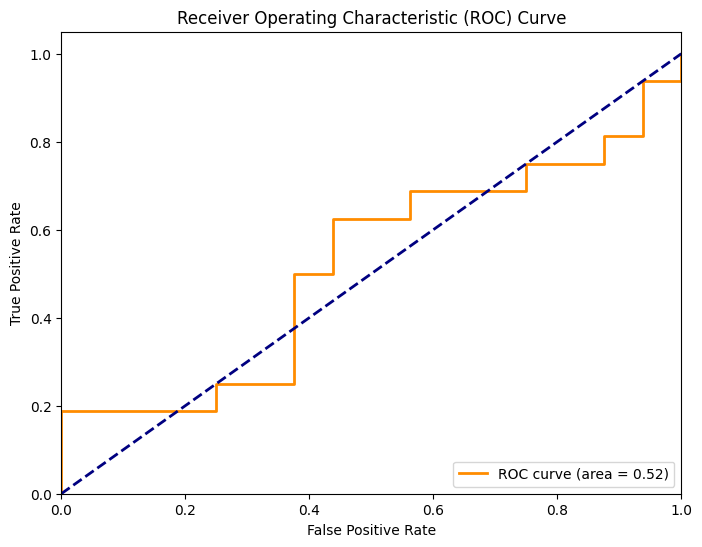

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Identify numerical and categorical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Scale numerical features
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode categorical features
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Apply the preprocessor to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

print(f"Numerical columns to preprocess: {numerical_cols}")
print(f"Categorical columns to preprocess: {categorical_cols}")

# Train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for small datasets
log_reg_model.fit(X_train_processed, y_train)

# Make predictions
y_pred = log_reg_model.predict(X_test_processed)
y_pred_proba = log_reg_model.predict_proba(X_test_processed)[:, 1]

# Evaluate the model
print("\n--- Logistic Regression Model Performance ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.2f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [19]:
from sklearn.metrics import classification_report, roc_auc_score

# --- Training Set Metrics ---
print("\n--- Logistic Regression Model Performance (Training Set) ---")
y_train_pred = log_reg_model.predict(X_train_processed)
y_train_pred_proba = log_reg_model.predict_proba(X_train_processed)[:, 1]

print(classification_report(y_train, y_train_pred))

roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
print(f"ROC AUC Score (Train): {roc_auc_train:.2f}")

# --- Test Set Metrics (as previously calculated) ---
print("\n--- Logistic Regression Model Performance (Test Set) ---")
# y_pred and y_pred_proba for the test set are already available from the previous cell

print(classification_report(y_test, y_pred))

roc_auc_test = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score (Test): {roc_auc_test:.2f}")


--- Logistic Regression Model Performance (Training Set) ---
              precision    recall  f1-score   support

           0       0.65      0.62      0.63        64
           1       0.64      0.66      0.65        64

    accuracy                           0.64       128
   macro avg       0.64      0.64      0.64       128
weighted avg       0.64      0.64      0.64       128

ROC AUC Score (Train): 0.75

--- Logistic Regression Model Performance (Test Set) ---
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32

ROC AUC Score (Test): 0.52


It can be seen that the ROC AUC Curve is near 0.52 which means that the model is barely predicting and guessing at random. Further more it can be seen that the difference between train and test of all 4 metrics is roughly 0.04-0.05.

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Ensure numpy is imported

# all_model_results = [] # Moved to a dedicated initialization cell

def train_and_evaluate_model(model, model_name, X_train_proc, y_train, X_test_proc, y_test, dataset_type, results_list):
    print(f"\n--- Training {model_name} Model on {dataset_type} Data---")
    model.fit(X_train_proc, y_train)

    # Predictions for training set
    y_train_pred = model.predict(X_train_proc)
    y_train_pred_proba = model.predict_proba(X_train_proc)[:, 1]

    # Predictions for test set
    y_test_pred = model.predict(X_test_proc)
    y_test_pred_proba = model.predict_proba(X_test_proc)[:, 1]

    # Calculate metrics for training set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='binary', zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, average='binary', zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, average='binary', zero_division=0)
    train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

    # Calculate metrics for test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='binary', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='binary', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='binary', zero_division=0)
    test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

    print(f"\n--- {model_name} Performance (Training Set - {dataset_type}) ---")
    print(classification_report(y_train, y_train_pred, zero_division=0))
    print(f"ROC AUC Score (Train): {train_roc_auc:.2f}")

    print(f"\n--- {model_name} Performance (Test Set - {dataset_type}) ---")
    print(classification_report(y_test, y_test_pred, zero_division=0))
    print(f"ROC AUC Score (Test): {test_roc_auc:.2f}")

    # Plot ROC Curve for test set
    fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {test_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name} ({dataset_type} Test Set)')
    plt.legend(loc="lower right")
    plt.show()

    results_list.append({
        'Model': model_name,
        'Dataset_Strategy': dataset_type,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Train_Precision': train_precision,
        'Test_Precision': test_precision,
        'Train_Recall': train_recall,
        'Test_Recall': test_recall,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'Train_ROC_AUC': train_roc_auc,
        'Test_ROC_AUC': test_roc_auc
    })


It can be seen that training complex models on the same data is leading to extreme overfitting. Hence, we will now use SMOTE and then train the models


--- Training Logistic Regression Model on Undersampled Data---

--- Logistic Regression Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.65      0.62      0.63        64
           1       0.64      0.66      0.65        64

    accuracy                           0.64       128
   macro avg       0.64      0.64      0.64       128
weighted avg       0.64      0.64      0.64       128

ROC AUC Score (Train): 0.75

--- Logistic Regression Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32

ROC AUC Score (Test): 0.52


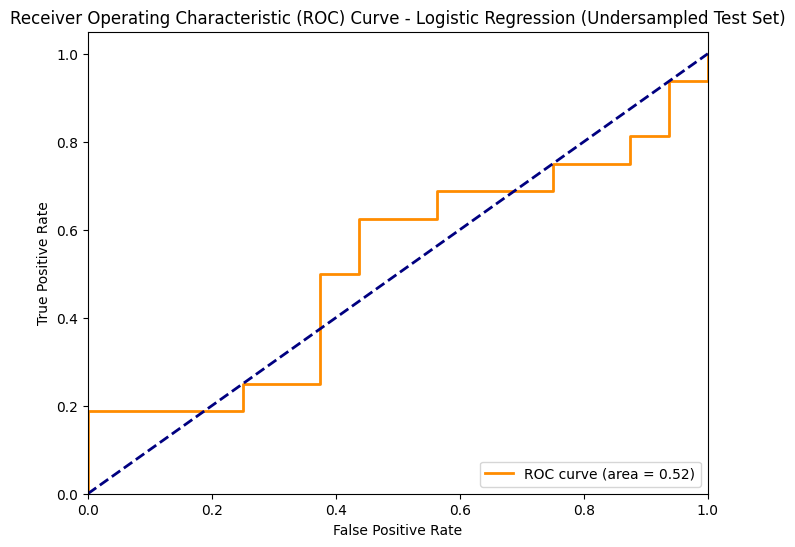


--- Training Decision Tree Model on Undersampled Data---

--- Decision Tree Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        64

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128

ROC AUC Score (Train): 1.00

--- Decision Tree Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.53      0.56      0.55        16
           1       0.53      0.50      0.52        16

    accuracy                           0.53        32
   macro avg       0.53      0.53      0.53        32
weighted avg       0.53      0.53      0.53        32

ROC AUC Score (Test): 0.53


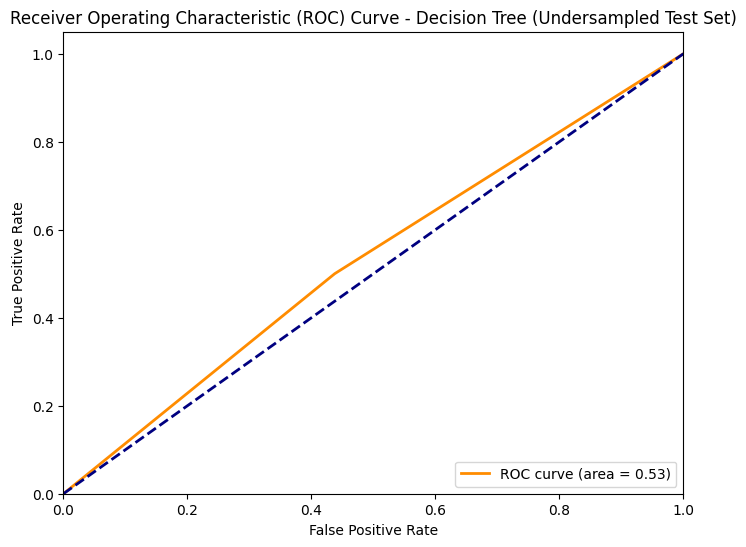


--- Training Random Forest Model on Undersampled Data---

--- Random Forest Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        64

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128

ROC AUC Score (Train): 1.00

--- Random Forest Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.47      0.44      0.45        16
           1       0.47      0.50      0.48        16

    accuracy                           0.47        32
   macro avg       0.47      0.47      0.47        32
weighted avg       0.47      0.47      0.47        32

ROC AUC Score (Test): 0.55


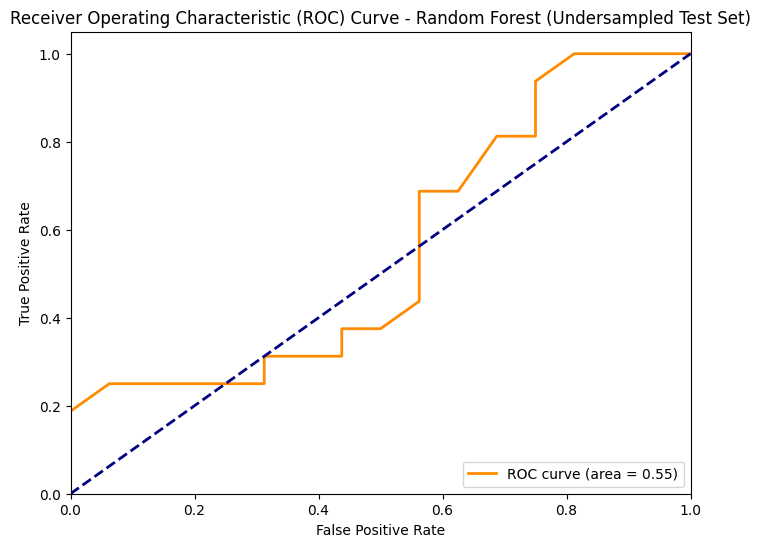


--- Training XGBoost Model on Undersampled Data---

--- XGBoost Performance (Training Set - Undersampled) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        64

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128

ROC AUC Score (Train): 1.00

--- XGBoost Performance (Test Set - Undersampled) ---
              precision    recall  f1-score   support

           0       0.47      0.50      0.48        16
           1       0.47      0.44      0.45        16

    accuracy                           0.47        32
   macro avg       0.47      0.47      0.47        32
weighted avg       0.47      0.47      0.47        32

ROC AUC Score (Test): 0.44


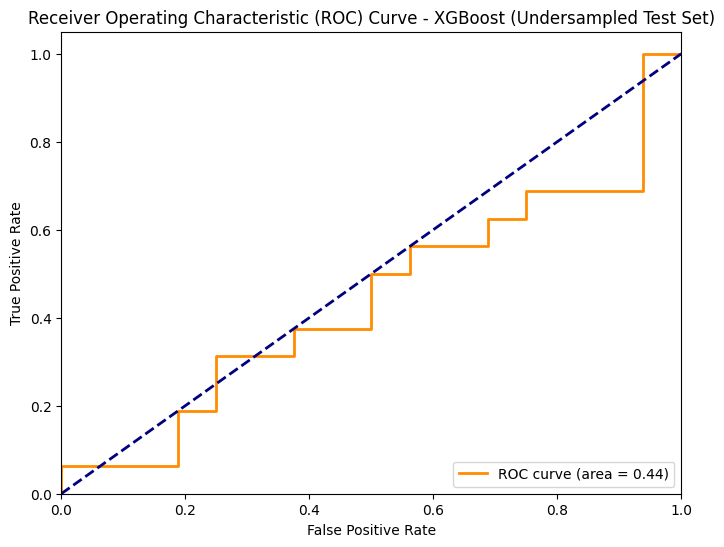

In [23]:
# --- Train models on Undersampled Data --- (as done previously)

# Necessary imports for data preparation and models
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Re-execute initial data loading and preprocessing for 'df' ---
# Load DataFrame (from bWIYFGfhgEuU)
df = pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

# Impute missing values (from wPP1BD5dldgF)
numerical_cols_with_nan = ['Income', 'Credit_Score', 'Loan_Balance']
for col in numerical_cols_with_nan:
    df[col].fillna(df[col].mean(), inplace=True)

# Standardize 'Employment_Status' (from 35jsGl3_nxZG)
df['Employment_Status'] = df['Employment_Status'].replace({
    'EMP': 'Employed',
    'employed': 'Employed',
    'EM': 'Employed'
})
df['Employment_Status'] = df['Employment_Status'].str.title()

# --- Data Preparation for Undersampled Data (copied from iEu4uKwxpRoM, 8i43s5eWc18G, 10d41c62, c1679519) ---
# Separate majority and minority classes
df_majority = df[df['Delinquent_Account'] == 0]
df_minority = df[df['Delinquent_Account'] == 1]
df_majority_undersampled = df_majority.sample(n=len(df_minority), random_state=42)
df_small = pd.concat([df_majority_undersampled, df_minority])
df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop 'Customer_ID' and define target/features
df_model_balanced = df_small.drop(columns=['Customer_ID'], errors='ignore')
X = df_model_balanced.drop('Delinquent_Account', axis=1)
y = df_model_balanced['Delinquent_Account']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical and categorical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), numerical_cols),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])

# Apply the preprocessor to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Logistic Regression
log_reg_model_us = LogisticRegression(random_state=42, solver='liblinear')
train_and_evaluate_model(log_reg_model_us, 'Logistic Regression', X_train_processed, y_train, X_test_processed, y_test, 'Undersampled', all_model_results)

# Decision Tree Classifier
dt_model_us = DecisionTreeClassifier(random_state=42)
train_and_evaluate_model(dt_model_us, 'Decision Tree', X_train_processed, y_train, X_test_processed, y_test, 'Undersampled', all_model_results)

# Random Forest Classifier
rf_model_us = RandomForestClassifier(random_state=42)
train_and_evaluate_model(rf_model_us, 'Random Forest', X_train_processed, y_train, X_test_processed, y_test, 'Undersampled', all_model_results)

# XGBoost Classifier
xgb_model_us = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
train_and_evaluate_model(xgb_model_us, 'XGBoost', X_train_processed, y_train, X_test_processed, y_test, 'Undersampled', all_model_results)



--- Preparing Data with SMOTE ---
Original X_train shape (before SMOTE): (400, 17)
y_train shape (before SMOTE): (400,)
X_train shape after processing and SMOTE: (672, 40)
y_train shape after SMOTE: (672,)
X_test shape after processing: (100, 40)
y_test shape: (100,)

--- Training Logistic Regression Model on SMOTE Data---

--- Logistic Regression Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       336
           1       0.66      0.74      0.69       336

    accuracy                           0.67       672
   macro avg       0.68      0.67      0.67       672
weighted avg       0.68      0.67      0.67       672

ROC AUC Score (Train): 0.72

--- Logistic Regression Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.83      0.57      0.68        84
           1       0.14      0.38      0.21        16

    accuracy                   

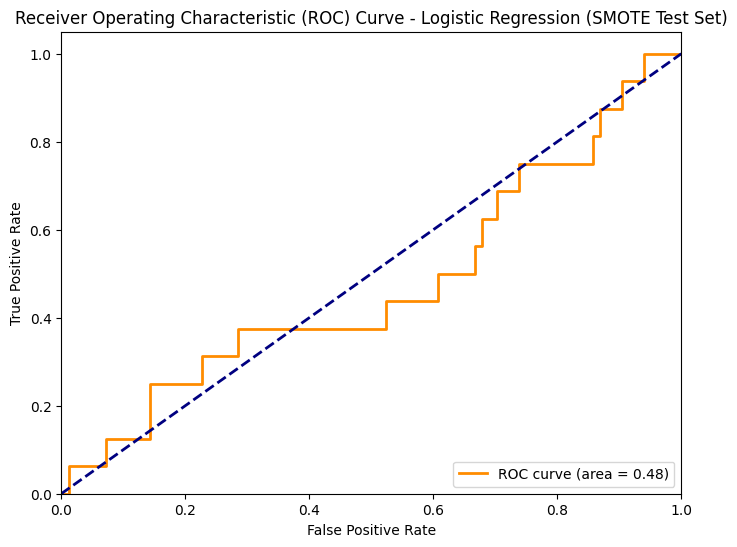


--- Training Decision Tree Model on SMOTE Data---

--- Decision Tree Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       336

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

ROC AUC Score (Train): 1.00

--- Decision Tree Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        84
           1       0.05      0.06      0.05        16

    accuracy                           0.64       100
   macro avg       0.43      0.41      0.42       100
weighted avg       0.69      0.64      0.66       100

ROC AUC Score (Test): 0.41


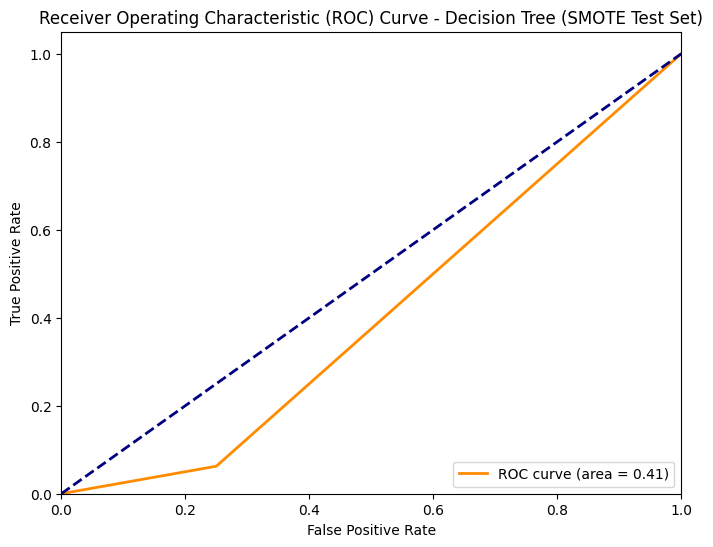


--- Training Random Forest Model on SMOTE Data---

--- Random Forest Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       336

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

ROC AUC Score (Train): 1.00

--- Random Forest Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.84      0.99      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.83       100
   macro avg       0.42      0.49      0.45       100
weighted avg       0.70      0.83      0.76       100

ROC AUC Score (Test): 0.45


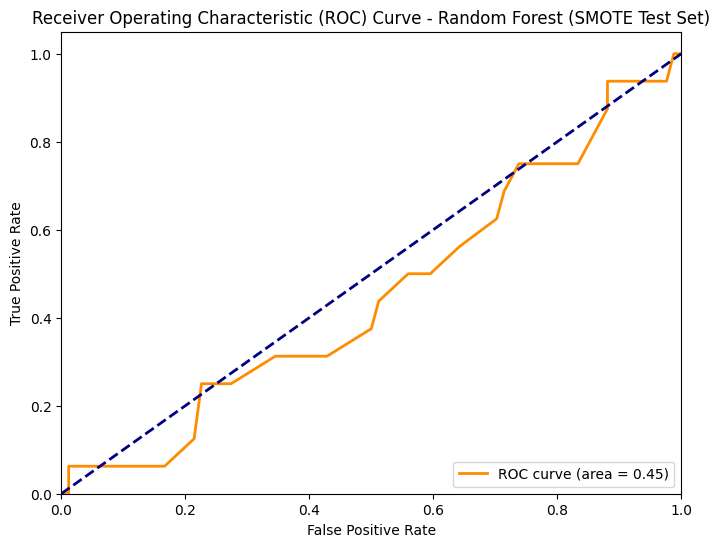


--- Training XGBoost Model on SMOTE Data---

--- XGBoost Performance (Training Set - SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       336

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

ROC AUC Score (Train): 1.00

--- XGBoost Performance (Test Set - SMOTE) ---
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        84
           1       0.00      0.00      0.00        16

    accuracy                           0.79       100
   macro avg       0.42      0.47      0.44       100
weighted avg       0.70      0.79      0.74       100

ROC AUC Score (Test): 0.36


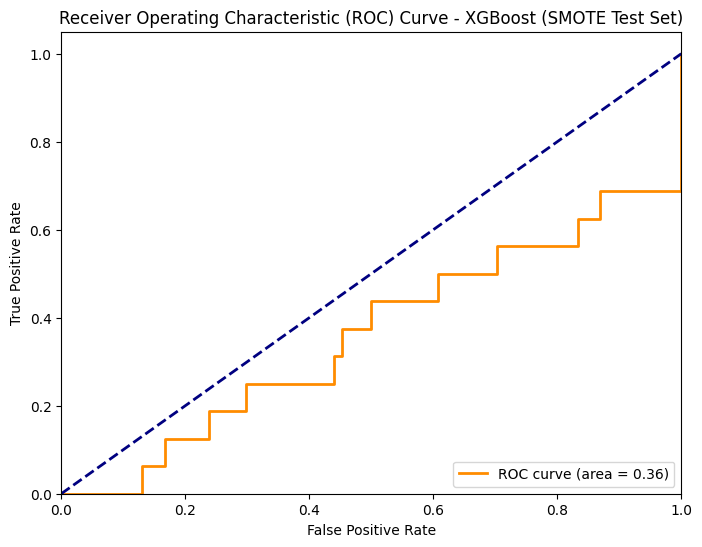


--- Comprehensive Model Performance Comparison ---


,Model,Dataset_Strategy,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC
0,Logistic Regression,Undersampled,0.64,0.59,0.64,0.59,0.66,0.62,0.65,0.61,0.75,0.52
1,Decision Tree,Undersampled,1.00,0.53,1.00,0.53,1.00,0.50,1.00,0.52,1.00,0.53
2,Random Forest,Undersampled,1.00,0.47,1.00,0.47,1.00,0.50,1.00,0.48,1.00,0.55
3,XGBoost,Undersampled,1.00,0.47,1.00,0.47,1.00,0.44,1.00,0.45,1.00,0.44
4,Logistic Regression,SMOTE,0.67,0.54,0.66,0.14,0.74,0.38,0.69,0.21,0.72,0.48
5,Decision Tree,SMOTE,1.00,0.64,1.00,0.05,1.00,0.06,1.00,0.05,1.00,0.41
6,Random Forest,SMOTE,1.00,0.83,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.45
7,XGBoost,SMOTE,1.00,0.79,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.36
8,Logistic Regression,Undersampled,0.64,0.59,0.64,0.59,0.66,0.62,0.65,0.61,0.75,0.52
9,Decision Tree,Undersampled,1.00,0.53,1.00,0.53,1.00,0.50,1.00,0.52,1.00,0.53


In [24]:
# --- Prepare data for SMOTE and train models ---
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n--- Preparing Data with SMOTE ---")

# --- Re-execute initial data loading and preprocessing for 'df' ---
# Load DataFrame (from bWIYFGfhgEuU)
df = pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

# Impute missing values (from wPP1BD5dldgF)
numerical_cols_with_nan = ['Income', 'Credit_Score', 'Loan_Balance']
for col in numerical_cols_with_nan:
    df[col].fillna(df[col].mean(), inplace=True)

# Standardize 'Employment_Status' (from 35jsGl3_nxZG)
df['Employment_Status'] = df['Employment_Status'].replace({
    'EMP': 'Employed',
    'employed': 'Employed',
    'EM': 'Employed'
})
df['Employment_Status'] = df['Employment_Status'].str.title()

# Start with the original processed df (after imputation and standardization)
df_for_smote = df.drop(columns=['Customer_ID'], errors='ignore')
X_smote_base = df_for_smote.drop('Delinquent_Account', axis=1)
y_smote_base = df_for_smote['Delinquent_Account']

# Split into training and test sets *before* SMOTE to prevent data leakage
X_train_raw_smote, X_test_raw_smote, y_train_raw_smote, y_test_raw_smote = train_test_split(
    X_smote_base, y_smote_base, test_size=0.2, random_state=42, stratify=y_smote_base
)

# Identify numerical and categorical columns for preprocessing
# These columns should be consistent as they derive from the same base X
numerical_cols_smote = X_smote_base.select_dtypes(include=np.number).columns.tolist()
categorical_cols_smote = X_smote_base.select_dtypes(include='object').columns.tolist()

# Create a ColumnTransformer for SMOTE data processing. Reusing the previous preprocessor might lead to issues if column names changed, so creating a new one.
smote_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), numerical_cols_smote),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols_smote)
    ])

# Fit and transform the preprocessor on the *training* data (before SMOTE)
X_train_processed_smote_initial = smote_preprocessor.fit_transform(X_train_raw_smote)
# Transform the *test* data using the fitted preprocessor
X_test_processed_smote = smote_preprocessor.transform(X_test_raw_smote)

# Apply SMOTE to the *processed training data*
smote = SMOTE(random_state=42)
X_train_processed_smote, y_train_processed_smote = smote.fit_resample(X_train_processed_smote_initial, y_train_raw_smote)

print(f"Original X_train shape (before SMOTE): {X_train_raw_smote.shape}")
print(f"y_train shape (before SMOTE): {y_train_raw_smote.shape}")
print(f"X_train shape after processing and SMOTE: {X_train_processed_smote.shape}")
print(f"y_train shape after SMOTE: {y_train_processed_smote.shape}")
print(f"X_test shape after processing: {X_test_processed_smote.shape}")
print(f"y_test shape: {y_test_raw_smote.shape}")

# --- Train models on SMOTE Data ---

# Logistic Regression
log_reg_model_smote = LogisticRegression(random_state=42, solver='liblinear')
train_and_evaluate_model(log_reg_model_smote, 'Logistic Regression', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# Decision Tree Classifier
dt_model_smote = DecisionTreeClassifier(random_state=42)
train_and_evaluate_model(dt_model_smote, 'Decision Tree', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# Random Forest Classifier
rf_model_smote = RandomForestClassifier(random_state=42)
train_and_evaluate_model(rf_model_smote, 'Random Forest', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# XGBoost Classifier
xgb_model_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
train_and_evaluate_model(xgb_model_smote, 'XGBoost', X_train_processed_smote, y_train_processed_smote, X_test_processed_smote, y_test_raw_smote, 'SMOTE', all_model_results)

# Display all results in a DataFrame
print("\n--- Comprehensive Model Performance Comparison ---")
display(pd.DataFrame(all_model_results).round(2))


In [33]:
smote_results_df = pd.DataFrame(all_model_results)
smote_training_results = smote_results_df[smote_results_df['Dataset_Strategy'] == 'SMOTE']
print("\n--- SMOTE Model Performance Comparison ---")
display(smote_training_results.round(2))


--- SMOTE Model Performance Comparison ---


,Model,Dataset_Strategy,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC
4,Logistic Regression,SMOTE,0.67,0.54,0.66,0.14,0.74,0.38,0.69,0.21,0.72,0.48
5,Decision Tree,SMOTE,1.00,0.64,1.00,0.05,1.00,0.06,1.00,0.05,1.00,0.41
6,Random Forest,SMOTE,1.00,0.83,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.45
7,XGBoost,SMOTE,1.00,0.79,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.36


SMOTE didn't do much for the generalization issue, we will be applying other methods to effectively generalize the model but before that we should run some tests to amke sure the columns are significant

In [51]:
"""
Statistical significance & predictability audit for Delinquency_prediction_dataset.xlsx

Goal: determine whether any feature in the dataset has a genuine,
statistically significant relationship with the target (Delinquent_Account),
and whether any ML model can beat the majority-class baseline on
cross-validation.

Run: python significance_test.py
Requires: pandas, numpy, scipy, scikit-learn, openpyxl
"""

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

DATA_PATH = "Delinquency_prediction_dataset.xlsx"
TARGET = "Delinquent_Account"
ALPHA = 0.05  # significance threshold


def load_data(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    # Normalize inconsistent category labels (e.g. "EMP" vs "employed" vs "Employed")
    df["Employment_Status"] = (
        df["Employment_Status"].str.lower().replace({"emp": "employed"})
    )
    return df


def numeric_feature_tests(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """Welch's t-test for each numeric feature: does its mean differ
    between delinquent (1) and non-delinquent (0) accounts?"""
    num_cols = [
        "Age", "Income", "Credit_Score", "Credit_Utilization",
        "Missed_Payments", "Loan_Balance", "Debt_to_Income_Ratio",
        "Account_Tenure",
    ]
    rows = []
    for col in num_cols:
        a = df.loc[df[target] == 1, col].dropna()
        b = df.loc[df[target] == 0, col].dropna()
        t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
        rows.append({
            "feature": col,
            "test": "Welch t-test",
            "statistic": round(t_stat, 3),
            "p_value": round(p_val, 4),
            "significant": p_val < ALPHA,
        })
    return pd.DataFrame(rows)


def categorical_feature_tests(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """Chi-square test of independence for each categorical feature
    (including the 6 monthly payment-status columns) against the target."""
    cat_cols = [
        "Employment_Status", "Credit_Card_Type", "Location",
        "Month_1", "Month_2", "Month_3", "Month_4", "Month_5", "Month_6",
    ]
    rows = []
    for col in cat_cols:
        contingency = pd.crosstab(df[col], df[target])
        chi2, p_val, dof, _ = stats.chi2_contingency(contingency)
        rows.append({
            "feature": col,
            "test": "Chi-square",
            "statistic": round(chi2, 3),
            "p_value": round(p_val, 4),
            "significant": p_val < ALPHA,
        })
    return pd.DataFrame(rows)


def correlation_check(df: pd.DataFrame, target: str) -> pd.Series:
    """Pearson correlation of numeric features with the target, as a
    quick sanity check alongside the formal hypothesis tests above."""
    num_cols = [
        "Age", "Income", "Credit_Score", "Credit_Utilization",
        "Missed_Payments", "Loan_Balance", "Debt_to_Income_Ratio",
        "Account_Tenure",
    ]
    return df[num_cols + [target]].corr()[target].drop(target).sort_values(
        key=abs, ascending=False
    )


def build_preprocessor(num_cols, cat_cols) -> ColumnTransformer:
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])


def model_benchmark(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """5-fold cross-validated AUC/accuracy/F1 for three standard classifiers,
    compared against the majority-class baseline. If models can't beat
    AUC=0.5 / the baseline accuracy, the dataset has no learnable signal."""
    month_cols = [f"Month_{i}" for i in range(1, 7)]
    df = df.copy()
    df["Missed_count"] = (df[month_cols] == "Missed").sum(axis=1)
    df["Late_count"] = (df[month_cols] == "Late").sum(axis=1)

    num_cols = [
        "Age", "Income", "Credit_Score", "Credit_Utilization",
        "Missed_Payments", "Loan_Balance", "Debt_to_Income_Ratio",
        "Account_Tenure", "Missed_count", "Late_count",
    ]
    cat_cols = ["Employment_Status", "Credit_Card_Type", "Location"]

    X = df[num_cols + cat_cols]
    y = df[target]
    pre = build_preprocessor(num_cols, cat_cols)

    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []
    for name, clf in models.items():
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
        acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
        f1 = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
        rows.append({
            "model": name,
            "AUC_mean": round(auc.mean(), 3),
            "AUC_std": round(auc.std(), 3),
            "accuracy_mean": round(acc.mean(), 3),
            "f1_mean": round(f1.mean(), 3),
        })

    baseline_acc = (y == y.mode()[0]).mean()
    rows.append({
        "model": "Baseline (majority class)",
        "AUC_mean": 0.5,
        "AUC_std": 0.0,
        "accuracy_mean": round(baseline_acc, 3),
        "f1_mean": 0.0,
    })
    return pd.DataFrame(rows)


def main():
    df = load_data(DATA_PATH)

    print("=" * 70)
    print("1. NUMERIC FEATURES vs TARGET (Welch's t-test)")
    print("=" * 70)
    num_results = numeric_feature_tests(df, TARGET)
    print(num_results.to_string(index=False))

    print()
    print("=" * 70)
    print("2. CATEGORICAL FEATURES vs TARGET (Chi-square test)")
    print("=" * 70)
    cat_results = categorical_feature_tests(df, TARGET)
    print(cat_results.to_string(index=False))

    print()
    print("=" * 70)
    print("3. CORRELATION CHECK (Pearson r, numeric features vs target)")
    print("=" * 70)
    print(correlation_check(df, TARGET).round(3).to_string())

    print()
    print("=" * 70)
    print("4. MODEL BENCHMARK vs MAJORITY-CLASS BASELINE (5-fold CV)")
    print("=" * 70)
    bench = model_benchmark(df, TARGET)
    print(bench.to_string(index=False))

    print()
    print("=" * 70)
    print("VERDICT")
    print("=" * 70)
    all_results = pd.concat([num_results, cat_results], ignore_index=True)
    n_sig = all_results["significant"].sum()
    n_total = len(all_results)
    best_auc = bench.loc[bench["model"] != "Baseline (majority class)", "AUC_mean"].max()

    print(f"Significant features (p < {ALPHA}): {n_sig} / {n_total}")
    print(f"Best model CV AUC: {best_auc} (random chance = 0.50)")
    if n_sig == 0 and best_auc <= 0.55:
        print(
            "\nConclusion: No feature shows a statistically significant relationship "
            "with the target, and no model beats random chance on cross-validation. "
            "The target does not appear to be derived from these features — likely a "
            "randomly/independently assigned label. The achievable ceiling for any "
            "model trained on this data is approximately the majority-class baseline."
        )
    else:
        print(
            "\nConclusion: Some signal detected — review the flagged features/models "
            "above before drawing further conclusions."
        )


if __name__ == "__main__":
    main()

1. NUMERIC FEATURES vs TARGET (Welch's t-test)
             feature         test  statistic  p_value  significant
                 Age Welch t-test      0.514   0.6083        False
              Income Welch t-test      0.984   0.3273        False
        Credit_Score Welch t-test      0.761   0.4481        False
  Credit_Utilization Welch t-test      0.851   0.3962        False
     Missed_Payments Welch t-test     -0.581   0.5621        False
        Loan_Balance Welch t-test     -0.091   0.9280        False
Debt_to_Income_Ratio Welch t-test      0.800   0.4256        False
      Account_Tenure Welch t-test     -0.846   0.3995        False

2. CATEGORICAL FEATURES vs TARGET (Chi-square test)
          feature       test  statistic  p_value  significant
Employment_Status Chi-square      2.108   0.5503        False
 Credit_Card_Type Chi-square      4.401   0.3544        False
         Location Chi-square      2.394   0.6637        False
          Month_1 Chi-square      4.492   0.1058 

Since the Columns are statistically Insignificant, it becomes meaningless to train Machine Learning model son this dataset even with techniques like SMOTE
